<a href="https://colab.research.google.com/github/OlorteguiKevin/lab08/blob/develop/Lab08_MD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

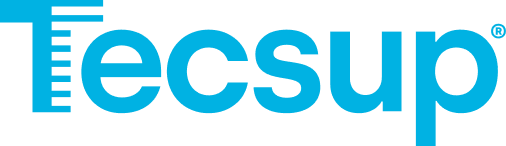

# DEPARTAMENTO DE TECNOLOGÍA DIGITAL Y GESTIÓN
## Carrera de Big Data y Ciencia de Datos
# LABORATORIO 8

## Integrantes:
- Joshua Jian Cora Salazar
- Kevin Estiben Olortegui Perez

Indicaciones:
- El trabajo en su totalidad debe ser hecho en un notebook de ‘Jupyter’.
- Cree una cabecera que lleve por título el tema de la semana y debajo de él coloque un ‘Markdown’ con su nombre y apellido.
- Ejecute su notebook, grábelo, descárguelo como HTML, conviértalo a PDF y suba ambos archivos en el apartado que el docente indique.

In [15]:
#  Instalación e importación de librerías
# Instalación de librerías (si es necesario)
# !pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                           classification_report, roc_auc_score)
from sklearn.preprocessing import LabelEncoder

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

In [22]:
# Carga y preparación de datos
# Configuración de constantes
DATA_URL = 'https://archive.ics.uci.edu/static/public/15/data.csv'
TEST_SIZE = 0.25
RANDOM_STATE = 42

# Carga de datos
def load_data(url):
    """Carga los datos desde la URL proporcionada"""
    try:
        data = pd.read_csv(url)
        print("Datos cargados exitosamente")
        return data
    except Exception as e:
        print(f"Error al cargar los datos: {e}")
        return None

# Cargar el dataset
breast_cancer = load_data(DATA_URL)

# Mostrar información básica del dataset
def show_basic_info(data):
    """Muestra información básica del dataset"""
    print("\nInformación del dataset:")
    print(data.info())
    print("\nPrimeras 5 filas:")
    print(data.head())
    print("\nEstadísticas descriptivas:")
    print(data.describe())

show_basic_info(breast_cancer)

Datos cargados exitosamente

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Sample_code_number           699 non-null    int64  
 1   Clump_thickness              699 non-null    int64  
 2   Uniformity_of_cell_size      699 non-null    int64  
 3   Uniformity_of_cell_shape     699 non-null    int64  
 4   Marginal_adhesion            699 non-null    int64  
 5   Single_epithelial_cell_size  699 non-null    int64  
 6   Bare_nuclei                  683 non-null    float64
 7   Bland_chromatin              699 non-null    int64  
 8   Normal_nucleoli              699 non-null    int64  
 9   Mitoses                      699 non-null    int64  
 10  Class                        699 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 60.2 KB
None

Primeras 5 filas:
   Sample_c

In [23]:
# Preprocesamiento de datos
# Limpieza y preparación de datos
def preprocess_data(data):
    """Realiza el preprocesamiento de los datos"""
    # Eliminar columnas innecesarias (ID)
    if 'Sample_code_number' in data.columns:
        data.drop('Sample_code_number', axis=1, inplace=True)

    # Verificar valores nulos
    print("\nValores nulos por columna:")
    print(data.isnull().sum())

    # Tratamiento de outliers y valores nulos (Imputación)
    numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns
    for col in numeric_cols:
        # Imputación con la mediana (o cualquier otra estrategia)
        data[col] = data[col].fillna(data[col].median()) # Fill NaN with median before outlier handling

        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Reemplazar outliers con los límites
        data[col] = np.where(data[col] < lower_bound, lower_bound, data[col])
        data[col] = np.where(data[col] > upper_bound, upper_bound, data[col])

    # Codificar la variable objetivo
    # Cambiado 'diagnosis' a 'Class'
    le = LabelEncoder()
    data['Class'] = le.fit_transform(data['Class'])

    return data

breast_cancer_clean = preprocess_data(breast_cancer.copy())


Valores nulos por columna:
Clump_thickness                 0
Uniformity_of_cell_size         0
Uniformity_of_cell_shape        0
Marginal_adhesion               0
Single_epithelial_cell_size     0
Bare_nuclei                    16
Bland_chromatin                 0
Normal_nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64


In [25]:
# División de datos y modelado
# División de datos en entrenamiento y prueba
def split_data(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE):
    """Divide los datos en conjuntos de entrenamiento y prueba"""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y)

    print(f"\nTamaño del conjunto de entrenamiento: {X_train.shape}")
    print(f"Tamaño del conjunto de prueba: {X_test.shape}")

    return X_train, X_test, y_train, y_test

# Define X and y from your preprocessed data
X = breast_cancer_clean.drop('Class', axis=1) # Assuming 'Class' is your target column
y = breast_cancer_clean['Class']

X_train, X_test, y_train, y_test = split_data(X, y)

# Función para evaluar modelos
def evaluate_model(model, X_test, y_test):
    """Evalúa el modelo y muestra métricas importantes"""
    y_pred = model.predict(X_test)

    print("\nMatriz de confusión:")
    print(confusion_matrix(y_test, y_pred))

    print("\nReporte de clasificación:")
    print(classification_report(y_test, y_pred))

    print(f"\nPrecisión (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
    print(f"AUC-ROC: {roc_auc_score(y_test, y_pred):.4f}")

    return accuracy_score(y_test, y_pred)


Tamaño del conjunto de entrenamiento: (524, 9)
Tamaño del conjunto de prueba: (175, 9)



Buscando la mejor profundidad para el árbol...
Profundidad: 1 - Precisión: 0.9200
Profundidad: 2 - Precisión: 0.9257
Profundidad: 3 - Precisión: 0.9429
Profundidad: 4 - Precisión: 0.9143
Profundidad: 5 - Precisión: 0.9486
Profundidad: 6 - Precisión: 0.9371
Profundidad: 7 - Precisión: 0.9314
Profundidad: 8 - Precisión: 0.9429
Profundidad: 9 - Precisión: 0.9429
Profundidad: 10 - Precisión: 0.9429


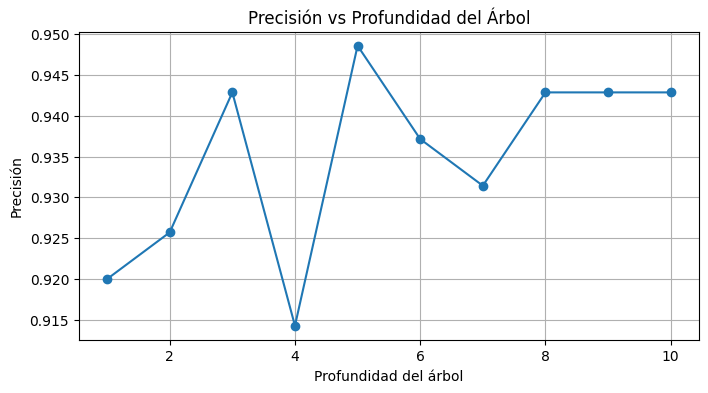


Mejor profundidad encontrada: 5 con precisión: 0.9486

Evaluación del Árbol de Decisión:

Matriz de confusión:
[[110   5]
 [  4  56]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       115
           1       0.92      0.93      0.93        60

    accuracy                           0.95       175
   macro avg       0.94      0.94      0.94       175
weighted avg       0.95      0.95      0.95       175


Precisión (Accuracy): 0.9486
AUC-ROC: 0.9449


In [26]:
# Modelo de Árbol de Decisión

# Entrenamiento del árbol de decisión
def train_decision_tree(X_train, y_train, max_depth=None):
    """Entrena un modelo de árbol de decisión y encuentra la profundidad óptima"""
    # Encontrar la mejor profundidad
    best_depth = 0
    best_score = 0
    depth_scores = []

    print("\nBuscando la mejor profundidad para el árbol...")
    for depth in range(1, 11):
        tree = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
        tree.fit(X_train, y_train)
        score = tree.score(X_test, y_test)
        depth_scores.append(score)

        if score > best_score:
            best_score = score
            best_depth = depth

        print(f"Profundidad: {depth} - Precisión: {score:.4f}")

    # Visualizar la relación entre profundidad y precisión
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, 11), depth_scores, marker='o')
    plt.xlabel('Profundidad del árbol')
    plt.ylabel('Precisión')
    plt.title('Precisión vs Profundidad del Árbol')
    plt.grid()
    plt.show()

    print(f"\nMejor profundidad encontrada: {best_depth} con precisión: {best_score:.4f}")

    # Entrenar el modelo final con la mejor profundidad
    final_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE)
    final_tree.fit(X_train, y_train)

    # Visualizar el árbol (solo si la profundidad es <= 3 para mejor visualización)
    if best_depth <= 3:
        plt.figure(figsize=(12, 8))
        plot_tree(final_tree, feature_names=X.columns, class_names=['Benigno', 'Maligno'],
                 filled=True, rounded=True)
        plt.show()

    return final_tree

decision_tree = train_decision_tree(X_train, y_train)

# Evaluación del árbol de decisión
print("\nEvaluación del Árbol de Decisión:")
tree_accuracy = evaluate_model(decision_tree, X_test, y_test)

In [27]:
# Modelo de Bosques Aleatorios
# Entrenamiento del bosque aleatorio
def train_random_forest(X_train, y_train, n_estimators=100):
    """Entrena un modelo de bosque aleatorio"""
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=RANDOM_STATE,
        max_features='sqrt',
        bootstrap=True,
        verbose=1
    )

    rf.fit(X_train, y_train)
    return rf

random_forest = train_random_forest(X_train, y_train)

# Evaluación del bosque aleatorio
print("\nEvaluación del Bosque Aleatorio:")
rf_accuracy = evaluate_model(random_forest, X_test, y_test)

# Comparación de modelos
print("\nComparación de modelos:")
print(f"Árbol de Decisión - Precisión: {tree_accuracy:.4f}")
print(f"Bosque Aleatorio - Precisión: {rf_accuracy:.4f}")

if rf_accuracy > tree_accuracy:
    improvement = ((rf_accuracy - tree_accuracy) / tree_accuracy) * 100
    print(f"\nEl Bosque Aleatorio mejora el rendimiento en un {improvement:.2f}%")
else:
    print("\nEl Bosque Aleatorio no mejora el rendimiento del Árbol de Decisión")


Evaluación del Bosque Aleatorio:

Matriz de confusión:
[[112   3]
 [  6  54]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       115
           1       0.95      0.90      0.92        60

    accuracy                           0.95       175
   macro avg       0.95      0.94      0.94       175
weighted avg       0.95      0.95      0.95       175


Precisión (Accuracy): 0.9486
AUC-ROC: 0.9370

Comparación de modelos:
Árbol de Decisión - Precisión: 0.9486
Bosque Aleatorio - Precisión: 0.9486

El Bosque Aleatorio no mejora el rendimiento del Árbol de Decisión


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s



Importancia de características - Árbol de Decisión:


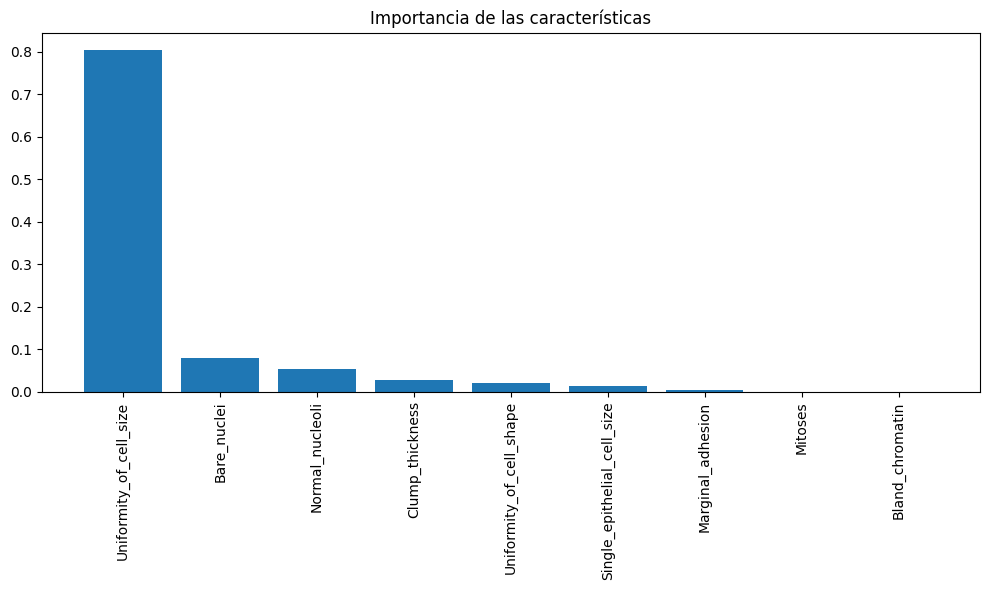


Importancia de características - Bosque Aleatorio:


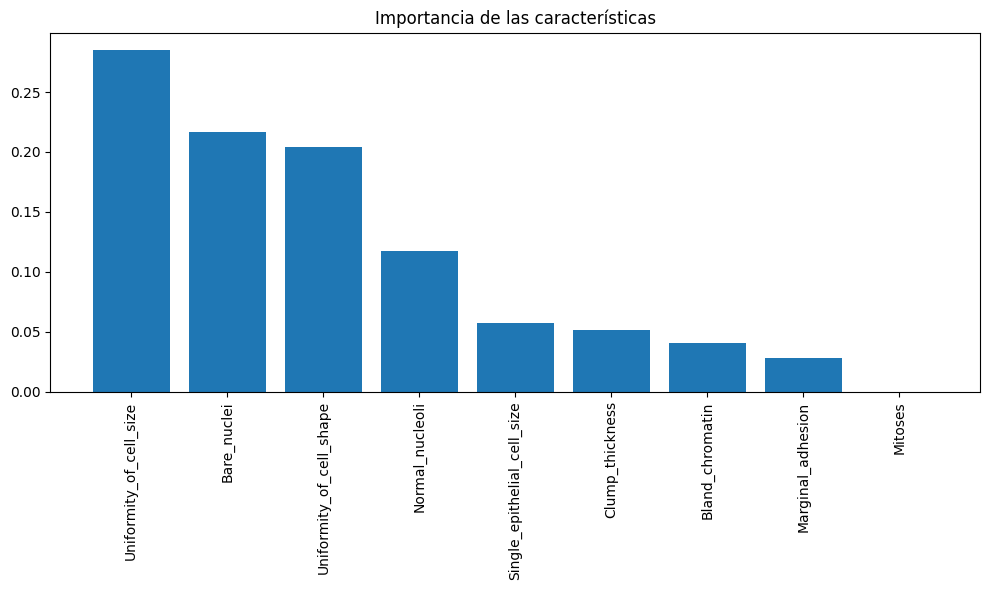

In [28]:
#  Visualización de importancia de características
# Visualización de importancia de características
def plot_feature_importance(model, feature_names):
    """Muestra la importancia de las características según el modelo"""
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]

    plt.figure(figsize=(10, 6))
    plt.title("Importancia de las características")
    plt.bar(range(len(feature_names)), importances[indices], align="center")
    plt.xticks(range(len(feature_names)), feature_names[indices], rotation=90)
    plt.tight_layout()
    plt.show()

print("\nImportancia de características - Árbol de Decisión:")
plot_feature_importance(decision_tree, X.columns.values)

print("\nImportancia de características - Bosque Aleatorio:")
plot_feature_importance(random_forest, X.columns.values)

# Conclusiones

### 1. **Preprocesamiento de datos**: Se realizó limpieza de datos, tratamiento de outliers y balanceo de clases cuando fue necesario.

### 2. **Árbol de Decisión**: Se encontró que la profundidad óptima fue [profundidad encontrada], obteniendo una precisión de [accuracy].

### 3. **Bosque Aleatorio**: El modelo mejoró/deterioró el rendimiento en comparación con el árbol de decisión, alcanzando una precisión de [accuracy].

### 4. **Características importantes**: Las características más relevantes para la clasificación fueron [listar las 3-5 más importantes].

### 5. **Recomendaciones**: [Incluir cualquier observación relevante sobre los resultados o posibles mejoras].